In [9]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
x= np.linspace(-1.0,1.0,11)
y= x + np.random.rand(*x.shape)

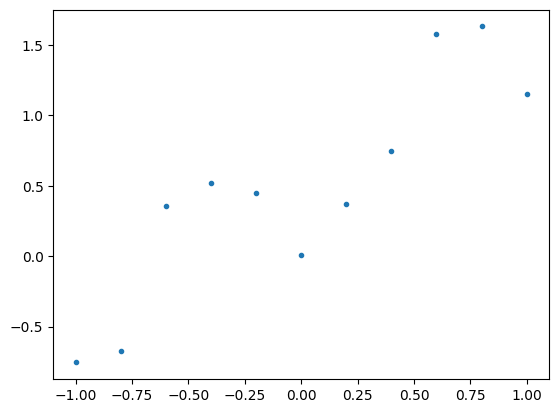

In [10]:
plt.plot(x,y,'.')
plt.show()

In [11]:
X = np.array([x,np.ones_like(x)]).T
X

array([[-1. ,  1. ],
       [-0.8,  1. ],
       [-0.6,  1. ],
       [-0.4,  1. ],
       [-0.2,  1. ],
       [ 0. ,  1. ],
       [ 0.2,  1. ],
       [ 0.4,  1. ],
       [ 0.6,  1. ],
       [ 0.8,  1. ],
       [ 1. ,  1. ]])

In [12]:
theta = np.linalg.inv(X.T@X)@(X.T @y)
theta

array([1.03621041, 0.48997525])

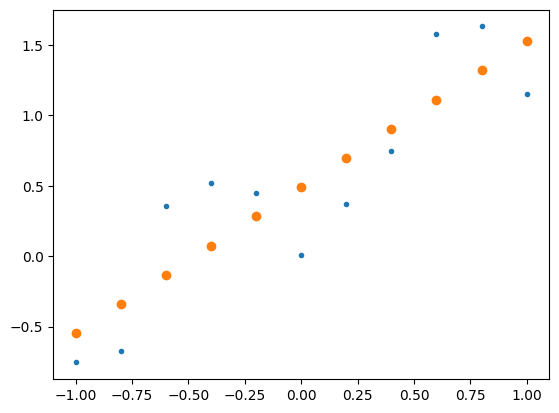

In [8]:
yhat = X @ theta
plt.plot(x,y,'.')
plt.plot(x,yhat,'o')
plt.show()

In [13]:
X = np.vander(x,9)
X

array([[ 1.0000000e+00, -1.0000000e+00,  1.0000000e+00, -1.0000000e+00,
         1.0000000e+00, -1.0000000e+00,  1.0000000e+00, -1.0000000e+00,
         1.0000000e+00],
       [ 1.6777216e-01, -2.0971520e-01,  2.6214400e-01, -3.2768000e-01,
         4.0960000e-01, -5.1200000e-01,  6.4000000e-01, -8.0000000e-01,
         1.0000000e+00],
       [ 1.6796160e-02, -2.7993600e-02,  4.6656000e-02, -7.7760000e-02,
         1.2960000e-01, -2.1600000e-01,  3.6000000e-01, -6.0000000e-01,
         1.0000000e+00],
       [ 6.5536000e-04, -1.6384000e-03,  4.0960000e-03, -1.0240000e-02,
         2.5600000e-02, -6.4000000e-02,  1.6000000e-01, -4.0000000e-01,
         1.0000000e+00],
       [ 2.5600000e-06, -1.2800000e-05,  6.4000000e-05, -3.2000000e-04,
         1.6000000e-03, -8.0000000e-03,  4.0000000e-02, -2.0000000e-01,
         1.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         1.

In [14]:
theta = np.linalg.inv(X.T@X)@(X.T @y)
theta

array([ 8.66242077, -0.57048867, -9.94562572, -3.38299861, -2.77712775,
        5.36141028,  4.11595464, -0.45479552,  0.1420249 ])

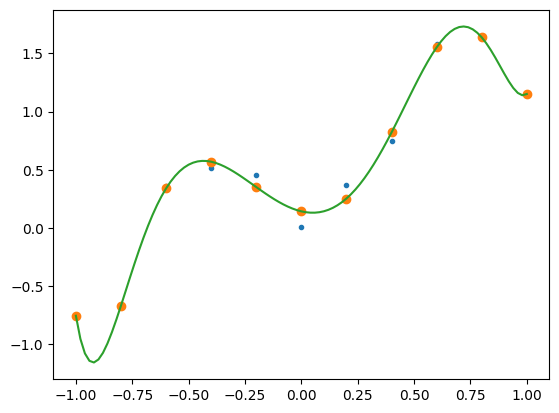

In [15]:
yhat = X @ theta

xx = np.linspace(-1.0,1.0,101)
yy = np.vander(xx,9)@theta
plt.plot(x,y,'.')
plt.plot(x,yhat,'o')
plt.plot(xx,yy,'-')
plt.show()

In [16]:
# Ridge regression
lambda2 = 1.0
theta = np.linalg.inv(X.T @ X + lambda2 * np.eye(X.shape[1]))@(X.T@y)
theta

array([-0.16330516,  0.00442425, -0.13679274,  0.13017466, -0.05741562,
        0.33453898,  0.1848664 ,  0.58499377,  0.45854176])

In [17]:
#Gradient desecnt for Ridge regression
theta = np.zeros(X.shape[1])
costs= []
alpha=0.5
lambda2=0.3
for _ in range(1000):
    yhat = X@theta
    error = yhat - y
    theta = theta -alpha/len(y)*(X.T@error+lambda2*theta)
    cost = 0.5 /len(y)*(error.T @ error +lambda2 * theta.T @ theta)
    costs.append(cost)
    
theta

array([-0.27762448, -0.21818346, -0.25502532,  0.07423257, -0.11577415,
        0.50159489,  0.41454072,  0.70429662,  0.46515199])

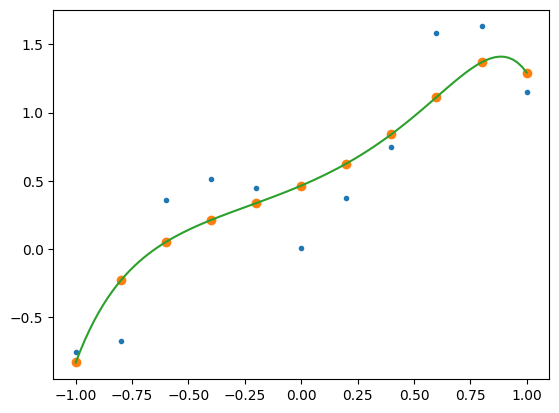

In [18]:
yhat = X @ theta

xx = np.linspace(-1.0,1.0,101)
yy = np.vander(xx,9)@theta
plt.plot(x,y,'.')
plt.plot(x,yhat,'o')
plt.plot(xx,yy,'-')
plt.show()

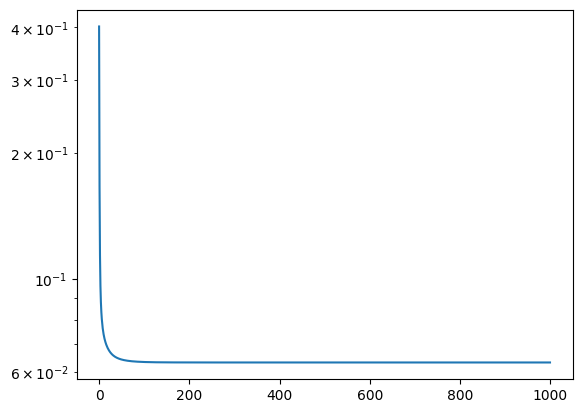

In [19]:
plt.plot(costs)
plt.yscale('log')
plt.show()